#About Data

shipment_id: Unique ID of the shipment

origin_city: Starting city

destination_city: Delivery city

pickup_date: Date of pickup (YYYY-MM-DD)

delivery_date: Date of delivery (YYYY-MM-DD)

weight_kg: Weight of the parcel in kilograms

distance_km: Distance between origin and destination

delivery_status: Delivered / Failed / Delayed

cost: Delivery cost in INR

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Loading the dataset
df = pd.read_csv('logistics_shipments_5000.csv')
df.head()

,shipment_id,origin_city,destination_city,pickup_date,delivery_date,weight_kg,distance_km,delivery_status,cost
0,SHP00001,Bangalore,Bangalore,2023-06-21,2023-06-27,27.37,1615.4,Delivered,1395.27
1,SHP00002,Pune,Ahmedabad,2023-05-24,2023-05-30,41.73,42.9,Delivered,275.21
2,SHP00003,Pune,Pune,2023-10-31,2023-11-12,6.69,381.7,Delayed,359.63
3,SHP00004,Pune,Ahmedabad,2023-06-02,2023-06-03,6.92,1313.3,Delivered,1084.87
4,SHP00005,Hyderabad,Ahmedabad,2023-03-30,2023-04-02,28.06,757.8,Delivered,753.08


In [3]:
df.shape

(5000, 9)

In [4]:
df.columns

Index(['shipment_id', 'origin_city', 'destination_city', 'pickup_date',
       'delivery_date', 'weight_kg', 'distance_km', 'delivery_status', 'cost'],
      dtype='object')

# Data Cleaning

In [5]:
#Checked missing values,there are no missing values in this dataset

df.isna().sum()

shipment_id         0
origin_city         0
destination_city    0
pickup_date         0
delivery_date       0
weight_kg           0
distance_km         0
delivery_status     0
cost                0
dtype: int64

In [6]:
#Checking Datatypes of coloumns 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shipment_id       5000 non-null   object 
 1   origin_city       5000 non-null   object 
 2   destination_city  5000 non-null   object 
 3   pickup_date       5000 non-null   object 
 4   delivery_date     5000 non-null   object 
 5   weight_kg         5000 non-null   float64
 6   distance_km       5000 non-null   float64
 7   delivery_status   5000 non-null   object 
 8   cost              5000 non-null   float64
dtypes: float64(3), object(6)
memory usage: 351.7+ KB


In [7]:
#Converting Date columns to datetime format

df['pickup_date'] = pd.to_datetime(df['pickup_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])

df.info()  #Other Columns are in right format

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   shipment_id       5000 non-null   object        
 1   origin_city       5000 non-null   object        
 2   destination_city  5000 non-null   object        
 3   pickup_date       5000 non-null   datetime64[ns]
 4   delivery_date     5000 non-null   datetime64[ns]
 5   weight_kg         5000 non-null   float64       
 6   distance_km       5000 non-null   float64       
 7   delivery_status   5000 non-null   object        
 8   cost              5000 non-null   float64       
dtypes: datetime64[ns](2), float64(3), object(4)
memory usage: 351.7+ KB


# Data Analysis

In [8]:
# Adding delivery duration in days
df['delivery_days'] = (df['delivery_date'] - df['pickup_date']).dt.days
df.head()   # So now we have number of days it took to deliver the package

,shipment_id,origin_city,destination_city,pickup_date,delivery_date,weight_kg,distance_km,delivery_status,cost,delivery_days
0,SHP00001,Bangalore,Bangalore,2023-06-21,2023-06-27,27.37,1615.4,Delivered,1395.27,6
1,SHP00002,Pune,Ahmedabad,2023-05-24,2023-05-30,41.73,42.9,Delivered,275.21,6
2,SHP00003,Pune,Pune,2023-10-31,2023-11-12,6.69,381.7,Delayed,359.63,12
3,SHP00004,Pune,Ahmedabad,2023-06-02,2023-06-03,6.92,1313.3,Delivered,1084.87,1
4,SHP00005,Hyderabad,Ahmedabad,2023-03-30,2023-04-02,28.06,757.8,Delivered,753.08,3


In [9]:
# Average delivery time per city pair
avg_delivery_time = df.groupby(['origin_city', 'destination_city'])['delivery_days'].mean().reset_index().sort_values(by='delivery_days', ascending=False)
avg_delivery_time.head()

,origin_city,destination_city,delivery_days
23,Chennai,Pune,6.092105
20,Chennai,Hyderabad,5.985507
37,Hyderabad,Kolkata,5.875000
45,Kolkata,Kolkata,5.813333
18,Chennai,Chennai,5.682353


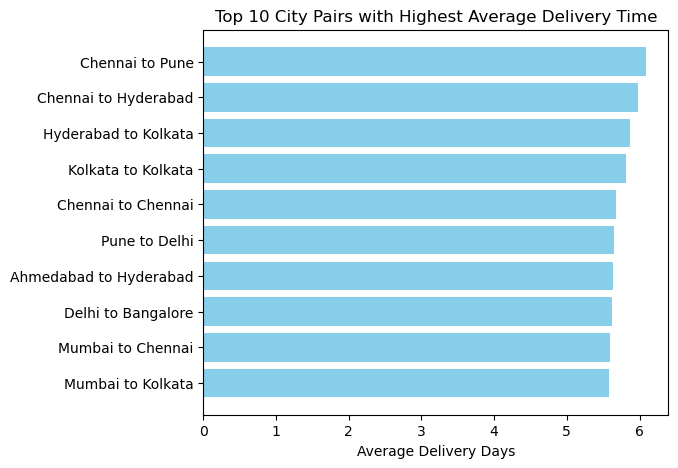

In [10]:
#Combining City Pairs
avg_delivery_time['city_pair'] = avg_delivery_time['origin_city'] + " to " + avg_delivery_time['destination_city']

plt.figure(figsize=(6, 5))
plt.barh(avg_delivery_time['city_pair'].head(10), avg_delivery_time['delivery_days'].head(10), color='skyblue')
plt.xlabel('Average Delivery Days')
plt.title('Top 10 City Pairs with Highest Average Delivery Time')
plt.gca().invert_yaxis()  # Highest on top
plt.show()

In [11]:
# Top 5 city pairs with highest average cost per kg
df['cost_per_kg'] = df['cost'] / df['weight_kg']
top_cost_pairs = df.groupby(['origin_city', 'destination_city'])['cost_per_kg'].mean().reset_index().sort_values(by='cost_per_kg', ascending=False).head(5)
top_cost_pairs

,origin_city,destination_city,cost_per_kg
50,Mumbai,Chennai,127.352533
21,Chennai,Kolkata,125.393372
43,Kolkata,Delhi,125.198546
22,Chennai,Mumbai,119.589558
27,Delhi,Delhi,119.207020


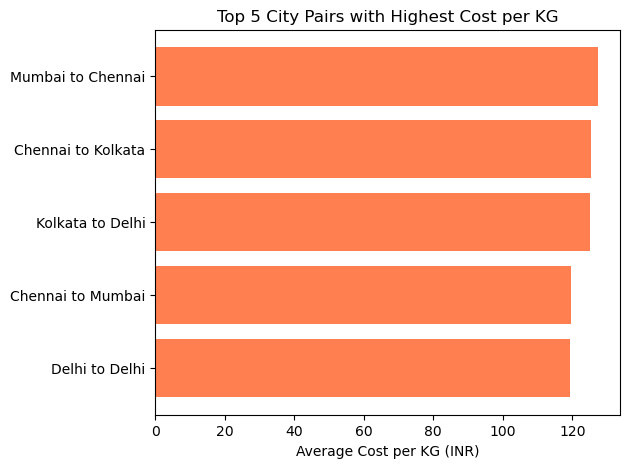

In [12]:
# Combining city pairs
top_cost_pairs['city_pair'] = top_cost_pairs['origin_city'] + " to " + top_cost_pairs['destination_city']

plt.figure(figsize=(6, 5))
plt.barh(top_cost_pairs['city_pair'], top_cost_pairs['cost_per_kg'], color='coral')
plt.xlabel('Average Cost per KG (INR)')
plt.title('Top 5 City Pairs with Highest Cost per KG')
plt.gca().invert_yaxis()  # Show highest cost at the top
plt.show()

In [16]:
# Delivery success rate per origin city

success_counts = df[df['delivery_status'] == 'Delivered'].groupby('origin_city').size()
total_counts = df.groupby('origin_city').size()
success_rate = (success_counts / total_counts).sort_values(ascending=False).head(10)
success_rate

origin_city
Bangalore    0.772581
Delhi        0.764228
Chennai      0.741935
Ahmedabad    0.739403
Hyderabad    0.735197
Mumbai       0.724638
Kolkata      0.724247
Pune         0.723765
dtype: float64

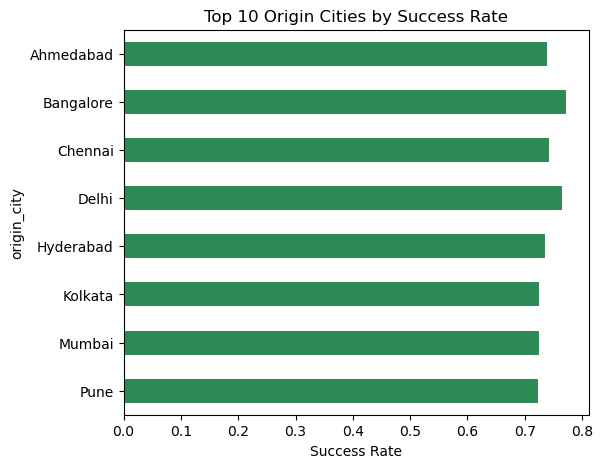

In [30]:
success_rate.plot(kind='barh', figsize=(6, 5), color='seagreen')
plt.title('Top 10 Origin Cities by Success Rate')
plt.xlabel('Success Rate')
plt.gca().invert_yaxis()
plt.show()

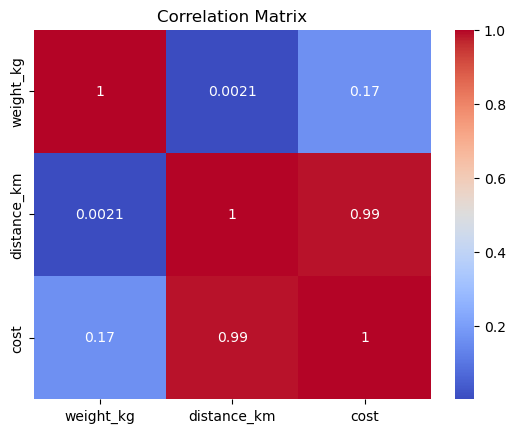

In [19]:
# Correlation analysis Between weight,cost and distance
correlations = df[['weight_kg', 'distance_km', 'cost']].corr()
sns.heatmap(correlations, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()  #We can see there is strong positive correlation between distance and cost 

# Linear Regression Model (Optional / Bonus Task)

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn import metrics

y = df['cost']
X = df.drop(columns=['cost', 'shipment_id', 'pickup_date', 'delivery_date','destination_city','origin_city','delivery_status','delivery_days','cost_per_kg'])  # Remove unused columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3750, 2)
Test shape: (1250, 2)


In [23]:
X_train

,weight_kg,distance_km
4884,23.08,706.9
3163,22.50,763.6
490,32.91,1818.3
862,12.05,718.8
1740,17.07,1614.4
...,...,...
4426,0.70,342.3
466,14.11,857.9
3092,20.75,1419.6
3772,28.39,1856.3


In [24]:
X_test

,weight_kg,distance_km
1501,26.51,188.1
2586,35.95,1616.9
2653,3.13,429.8
1055,34.14,805.3
705,13.13,1833.8
...,...,...
4141,41.15,587.0
3168,35.38,1241.7
2478,47.56,1393.7
4214,10.70,1911.8


In [25]:
# Standard scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=scaler.get_feature_names_out(),
    index=X_train.index)

In [26]:
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=scaler.get_feature_names_out(),
    index=X_test.index)

In [28]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("R² Score:", metrics.r2_score(y_test, y_pred)*100)

MAE: 9.93934842332375
R² Score: 99.92969345476156


In [33]:
output_df = pd.DataFrame({'Actual': y_test})
output_df['Linear Regression Predictions'] = y_pred

output_df

,Actual,Linear Regression Predictions
1501,322.33,323.949612
2586,1456.82,1442.487456
2653,405.95,387.966902
1055,830.95,824.930935
705,1500.23,1490.718378
...,...,...
4141,700.13,696.402032
3168,1156.85,1158.330247
2478,1333.17,1333.342571
4214,1525.89,1537.017114


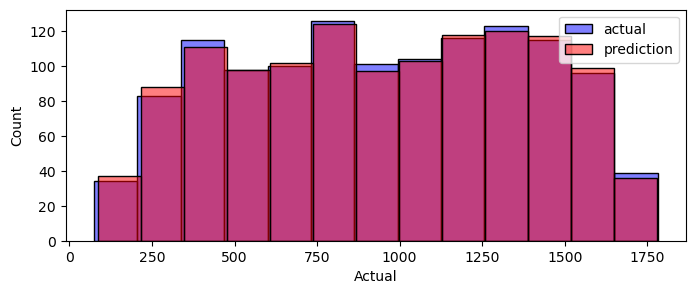

In [34]:
fig, ax = plt.subplots(figsize=(8,3))

sns.histplot(output_df['Actual'], color='blue', alpha=0.5, label="actual")
sns.histplot(output_df['Linear Regression Predictions'], color='red', alpha=0.5, label="prediction")

plt.legend()